# SilkRoute Benchmark — 02: Sales, Customer, Product & Store Insights
Deeper descriptive/diagnostic views across segments, stores, SKUs, and salespeople.

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = "../silkroute_benchmark_out"  # adjust if needed

with open(f"{OUT}/seed_manifest.json","r", encoding="utf-8") as f:
    manifest = json.load(f)

def load_table(name):
    return pd.read_parquet(f"{OUT}/{name}.parquet")

channels = load_table("channels")
stores = load_table("stores")
salespeople = load_table("salespeople")
customers = load_table("customers")
products = load_table("products")
skus = load_table("product_variants_skus")
variant_attributes = load_table("variant_attributes")
cat_attr_defs = load_table("category_attribute_definitions")
promotions = load_table("promotions")
transactions = load_table("transactions")
lines = load_table("transaction_lines")
inventory = load_table("inventory_snapshots")
returns = load_table("returns")

transactions["transaction_ts"] = pd.to_datetime(transactions["transaction_ts"])
transactions["month"] = transactions["transaction_ts"].dt.to_period("M").astype(str)

lines = lines.merge(
    transactions[["transaction_id","transaction_ts","month","channel_type","store_id","customer_id","salesperson_id"]],
    on="transaction_id", how="left"
)
lines = lines.merge(skus[["sku_id","product_id","base_price"]], on="sku_id", how="left")
lines = lines.merge(products[["product_id","category","subcategory","brand"]], on="product_id", how="left")

inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"])
promotions["start_date"] = pd.to_datetime(promotions["start_date"])
promotions["end_date"] = pd.to_datetime(promotions["end_date"])

hero_skus = set(manifest["pattern_sets"].get("hero_skus", []))
high_return_skus = set(manifest["pattern_sets"].get("high_return_skus", []))
top_salespeople = set(manifest["people_sets"].get("top_salespeople", []))
discount_heavy_salespeople = set(manifest["people_sets"].get("discount_heavy_salespeople", []))
underperforming_stores = set(manifest["meta"].get("underperforming_stores", []))
discount_heavy_stores = set(manifest["meta"].get("discount_heavy_stores", []))

def pct(x):
    return 100.0 * x


## A. Basket metrics (basket size, AOV, discount by channel)

In [3]:
basket_lines = lines.groupby("transaction_id").agg(
    basket_lines=("line_id","count"),
    basket_qty=("quantity","sum"),
    avg_discount=("discount","mean"),
).reset_index()

txm = transactions.merge(basket_lines, on="transaction_id", how="left")
txm["aov"] = txm["total_amount"].astype(float)

txm.groupby("channel_type").agg(
    tx=("transaction_id","count"),
    aov_mean=("aov","mean"),
    aov_median=("aov","median"),
    basket_lines_mean=("basket_lines","mean"),
    basket_qty_mean=("basket_qty","mean"),
    avg_discount=("avg_discount","mean"),
)


,tx,aov_mean,aov_median,basket_lines_mean,basket_qty_mean,avg_discount
channel_type,,,,,,
online,3700,67774.423414,22521.795,2.550541,2.677568,0.033965
store,7702,67627.275984,22433.860,2.659958,2.793300,0.052092


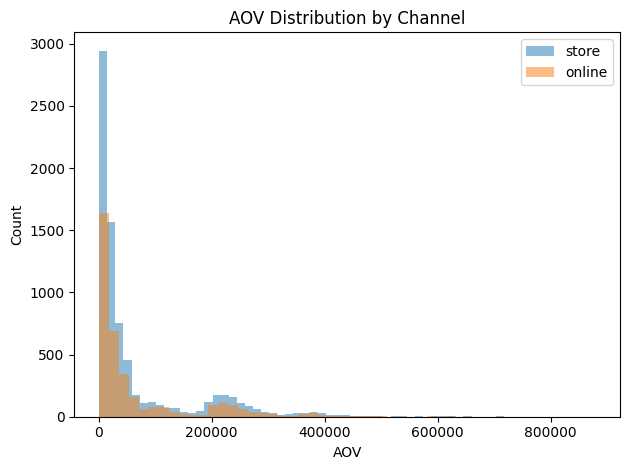

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111)
for ch in ["store","online"]:
    vals = txm.loc[txm["channel_type"]==ch, "aov"].astype(float)
    ax.hist(vals, bins=50, alpha=0.5, label=ch)
ax.set_title("AOV Distribution by Channel")
ax.set_xlabel("AOV"); ax.set_ylabel("Count")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


## B. Category mix by channel over time

In [5]:
cat_month = lines.groupby(["month","channel_type","category"])["line_total"].sum().reset_index()
cat_pivot = cat_month.pivot_table(index=["month","channel_type"], columns="category", values="line_total", aggfunc="sum").fillna(0.0)
cat_pivot["total"] = cat_pivot.sum(axis=1)
cat_share = cat_pivot.div(cat_pivot["total"], axis=0).drop(columns=["total"])
cat_share.head()


category              Attach & Addons  Electronics   Fashion
month   channel_type                                        
2025-01 online               0.097596     0.793846  0.108558
        store                0.086221     0.817690  0.096089
2025-02 online               0.077457     0.807861  0.114682
        store                0.082023     0.814183  0.103794
2025-03 online               0.093174     0.789325  0.117501

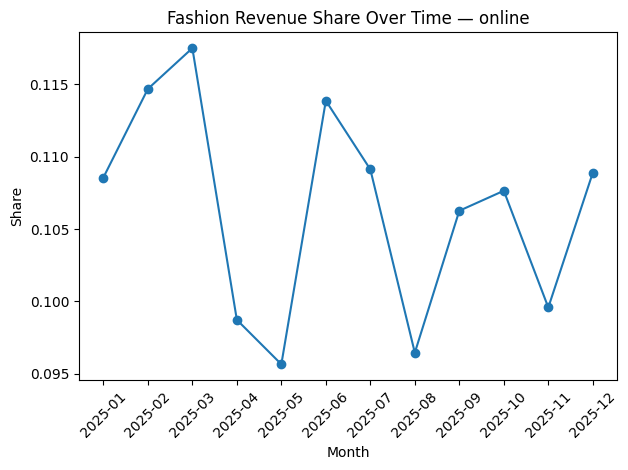

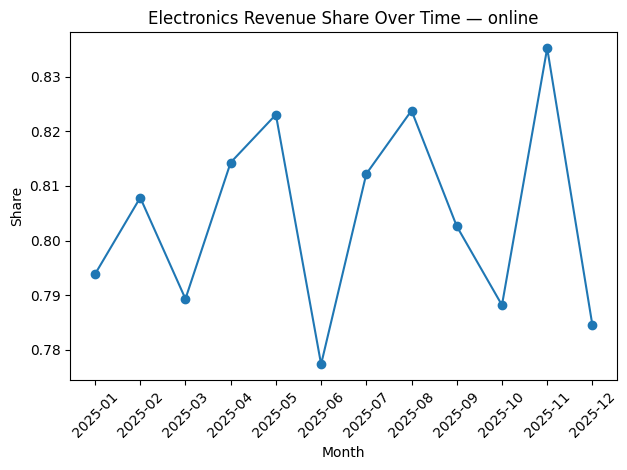

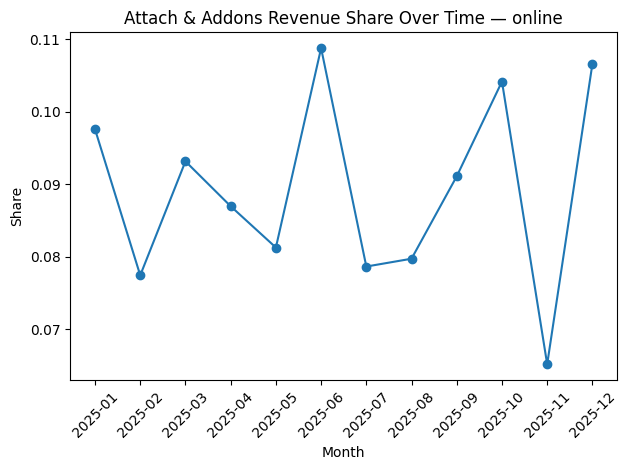

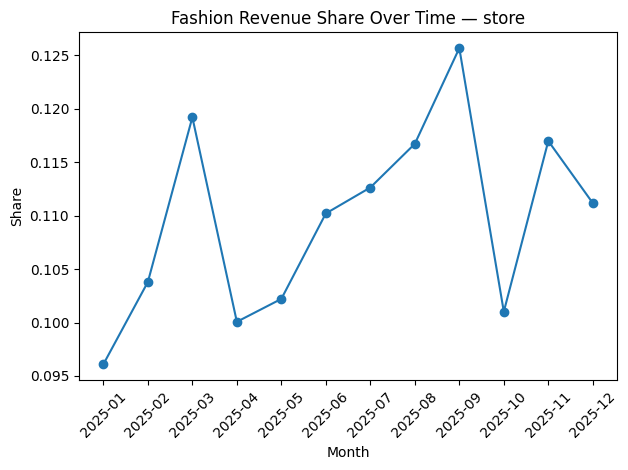

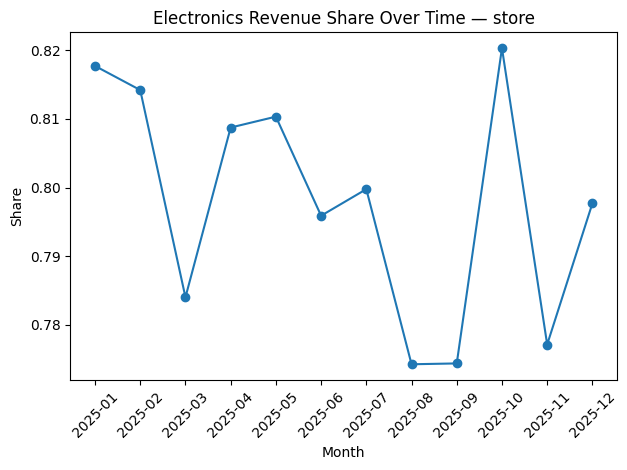

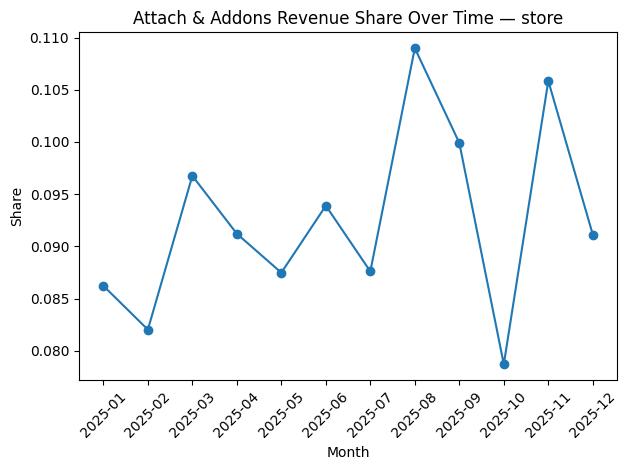

In [6]:
idx = cat_share.reset_index()
for ch in idx["channel_type"].unique():
    tmp = idx[idx["channel_type"]==ch].set_index("month")
    for cat in ["Fashion","Electronics","Attach & Addons"]:
        if cat in tmp:
            fig = plt.figure()
            ax = fig.add_subplot(111)
            ax.plot(tmp.index, tmp[cat], marker="o")
            ax.set_title(f"{cat} Revenue Share Over Time — {ch}")
            ax.set_xlabel("Month"); ax.set_ylabel("Share")
            ax.tick_params(axis="x", rotation=45)
            plt.tight_layout()
            plt.show()


## C. Customer segmentation behavior + cohorts

In [7]:
tx_seg = transactions.merge(customers[["customer_id","segment","first_purchase_date"]], on="customer_id", how="left")
tx_seg["first_purchase_date"] = pd.to_datetime(tx_seg["first_purchase_date"])

seg_kpis = tx_seg.groupby("segment").agg(
    customers=("customer_id","nunique"),
    tx=("transaction_id","count"),
    revenue=("total_amount","sum"),
).reset_index()
seg_kpis["rev_per_customer"] = seg_kpis["revenue"] / seg_kpis["customers"]
seg_kpis["tx_per_customer"] = seg_kpis["tx"] / seg_kpis["customers"]
seg_kpis.sort_values("revenue", ascending=False)


,segment,customers,tx,revenue,rev_per_customer,tx_per_customer
4,regular,872,3612,2.358556e+08,270476.572213,4.142202
1,loyal,335,3067,2.336842e+08,697564.833612,9.155224
3,price_sensitive,458,2250,1.405478e+08,306872.959214,4.912664
2,one_time,500,1318,8.483854e+07,169677.085180,2.636000
0,high_return,255,1155,7.670450e+07,300801.953412,4.529412


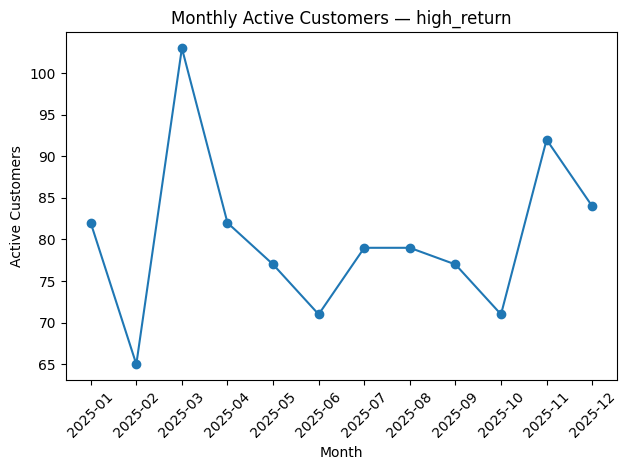

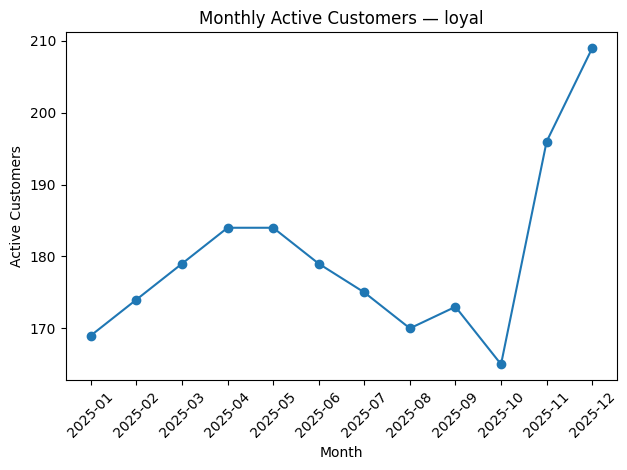

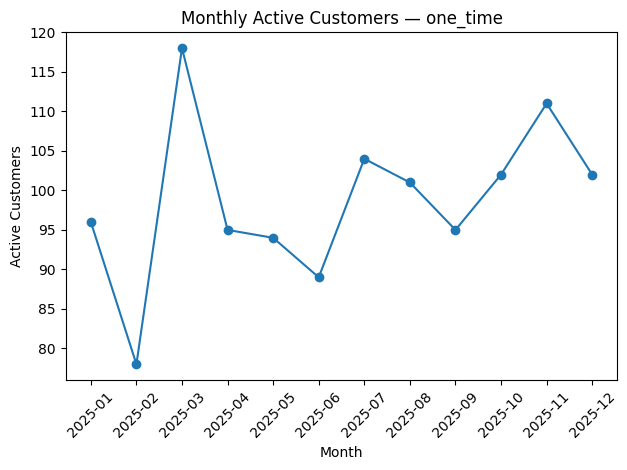

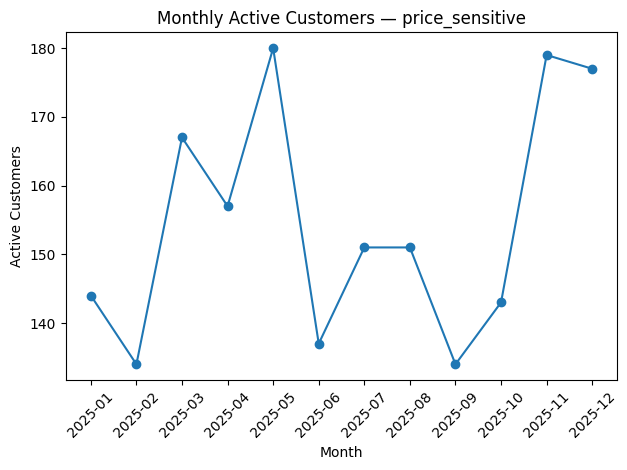

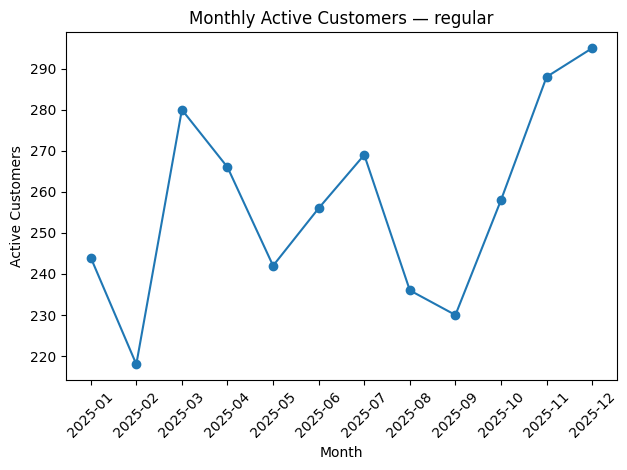

In [8]:
# Monthly active customers by segment
tx_seg["month"] = tx_seg["transaction_ts"].dt.to_period("M").astype(str)
mac = tx_seg.groupby(["month","segment"])["customer_id"].nunique().reset_index()

for seg in mac["segment"].unique():
    tmp = mac[mac["segment"]==seg].set_index("month")["customer_id"]
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(tmp.index, tmp.values, marker="o")
    ax.set_title(f"Monthly Active Customers — {seg}")
    ax.set_xlabel("Month"); ax.set_ylabel("Active Customers")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()


## D. Salesperson diagnostics: attach rate + discount culture

In [9]:
addon_lines = lines[lines["category"]=="Attach & Addons"].groupby("transaction_id").size().rename("addon_lines")
total_lines = lines.groupby("transaction_id").size().rename("total_lines")
basket = pd.concat([addon_lines, total_lines], axis=1).fillna(0)
basket["attach_rate"] = np.where(basket["total_lines"]>0, basket["addon_lines"]/basket["total_lines"], 0.0)

basket = basket.merge(transactions[["transaction_id","salesperson_id","channel_type","store_id","total_amount"]], left_index=True, right_on="transaction_id", how="left")

sp = basket[basket["channel_type"]=="store"].groupby("salesperson_id").agg(
    tx=("transaction_id","count"),
    avg_attach=("attach_rate","mean"),
    avg_aov=("total_amount","mean"),
).reset_index()

sp_disc = lines[lines["channel_type"]=="store"].groupby("salesperson_id")["discount"].mean().rename("avg_discount").reset_index()
sp = sp.merge(sp_disc, on="salesperson_id", how="left")

sp["is_top_seeded"] = sp["salesperson_id"].isin(top_salespeople)
sp["is_discount_heavy_seeded"] = sp["salesperson_id"].isin(discount_heavy_salespeople)

sp.sort_values(["avg_attach","tx"], ascending=False).head(20)


,salesperson_id,tx,avg_attach,avg_aov,avg_discount,is_top_seeded,is_discount_heavy_seeded
0,P0001,173,0.261919,84727.022717,0.004993,True,False
16,P0017,218,0.258767,93602.978028,0.005042,True,False
24,P0025,396,0.252540,84369.082677,0.050002,True,False
8,P0009,190,0.238596,84619.881895,0.005006,True,False
13,P0014,382,0.227312,64570.968010,0.080254,False,False
17,P0018,197,0.225381,73213.632792,0.020502,False,False
25,P0026,742,0.216846,60816.156348,0.148067,False,True
11,P0012,358,0.210864,65657.192933,0.079416,False,False
9,P0010,173,0.204115,57924.895376,0.018543,False,False
6,P0007,173,0.202532,59442.108150,0.085887,False,True


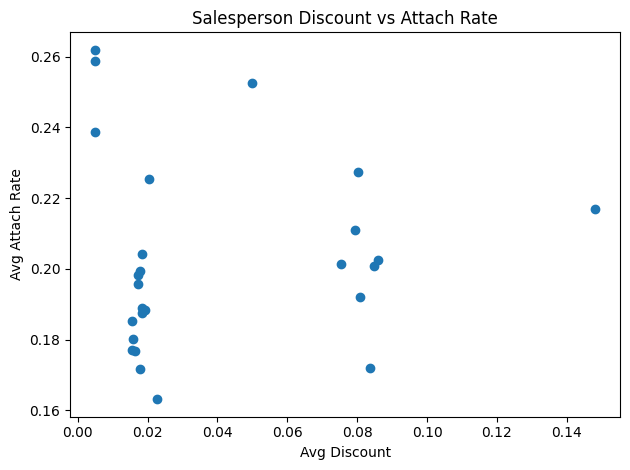

In [10]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(sp["avg_discount"], sp["avg_attach"])
ax.set_title("Salesperson Discount vs Attach Rate")
ax.set_xlabel("Avg Discount"); ax.set_ylabel("Avg Attach Rate")
plt.tight_layout()
plt.show()


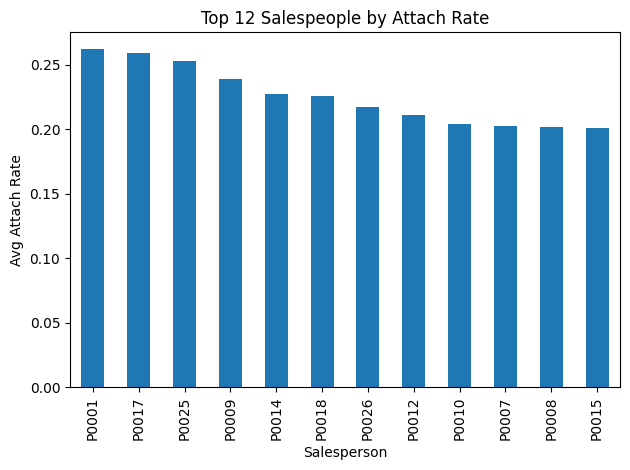

In [11]:
# Top attach performers
top_attach = sp.sort_values("avg_attach", ascending=False).head(12).set_index("salesperson_id")["avg_attach"]
fig = plt.figure()
ax = fig.add_subplot(111)
top_attach.plot(kind="bar", ax=ax)
ax.set_title("Top 12 Salespeople by Attach Rate")
ax.set_xlabel("Salesperson"); ax.set_ylabel("Avg Attach Rate")
plt.tight_layout()
plt.show()


## E. Store decomposition

In [12]:
store_tx = transactions[transactions["channel_type"]=="store"].groupby("store_id").agg(
    tx=("transaction_id","count"),
    revenue=("total_amount","sum"),
    aov=("total_amount","mean"),
).reset_index()

store_disc = lines[lines["channel_type"]=="store"].groupby("store_id")["discount"].mean().rename("avg_discount").reset_index()
store_tx = store_tx.merge(store_disc, on="store_id", how="left")
store_tx["is_under_seeded"] = store_tx["store_id"].isin(underperforming_stores)
store_tx["is_discount_heavy_seeded"] = store_tx["store_id"].isin(discount_heavy_stores)

store_tx.sort_values("revenue", ascending=False)


,store_id,tx,revenue,aov,avg_discount,is_under_seeded,is_discount_heavy_seeded
0,S001,1467,1.044831e+08,71222.267137,0.025605,False,False
4,S005,1462,1.022387e+08,69930.705534,0.069384,False,True
5,S006,1449,9.461834e+07,65299.062271,0.033407,False,False
3,S004,1498,9.181577e+07,61292.237623,0.113980,False,True
2,S003,922,6.741517e+07,73118.405629,0.015421,True,False
1,S002,904,6.029424e+07,66697.167113,0.027132,True,False


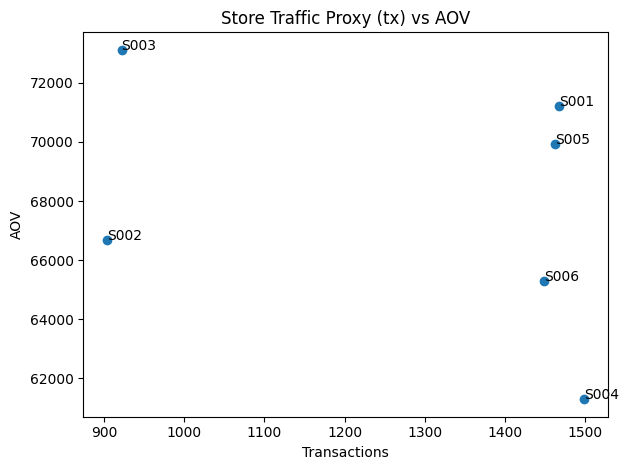

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(store_tx["tx"], store_tx["aov"])
for _, r in store_tx.iterrows():
    ax.annotate(r["store_id"], (r["tx"], r["aov"]))
ax.set_title("Store Traffic Proxy (tx) vs AOV")
ax.set_xlabel("Transactions"); ax.set_ylabel("AOV")
plt.tight_layout()
plt.show()


## F. Hero SKUs vs non-hero behavior

In [14]:
lines["is_hero"] = lines["sku_id"].isin(hero_skus)
hero_kpi = lines.groupby("is_hero").agg(
    lines=("line_id","count"),
    revenue=("line_total","sum"),
    avg_discount=("discount","mean"),
    avg_price=("unit_price","mean"),
).reset_index()
hero_kpi


,is_hero,lines,revenue,avg_discount,avg_price
0,False,25775,6.560516e+08,0.047632,26420.900392
1,True,4149,1.155790e+08,0.033422,27615.622391


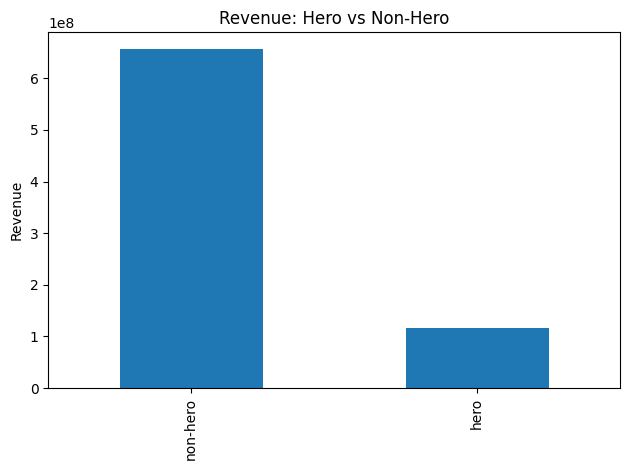

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)
tmp = lines.groupby("is_hero")["line_total"].sum()
tmp.index = tmp.index.map(lambda x: "hero" if x else "non-hero")
tmp.plot(kind="bar", ax=ax)
ax.set_title("Revenue: Hero vs Non-Hero")
ax.set_xlabel(""); ax.set_ylabel("Revenue")
plt.tight_layout()
plt.show()


## G. Promotions: simple before/after proxy

In [16]:
prom_by_product = promotions.groupby("product_id").agg(
    promo_start=("start_date","min"),
    promo_end=("end_date","max"),
    promo_cnt=("promo_id","count")
).reset_index()

l = lines.merge(prom_by_product, on="product_id", how="left")
l["in_promo_window"] = (l["transaction_ts"] >= l["promo_start"]) & (l["transaction_ts"] <= l["promo_end"])
l["in_promo_window"] = l["in_promo_window"].fillna(False)

promo_kpi = l.groupby("in_promo_window").agg(
    lines=("line_id","count"),
    revenue=("line_total","sum"),
    avg_discount=("discount","mean"),
).reset_index()
promo_kpi


,in_promo_window,lines,revenue,avg_discount
0,False,29489,7.633191e+08,0.044715
1,True,435,8.311509e+06,0.109864
